In [1]:
#Step 1: Import Libraries and Load Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\raynu\Desktop\Data Quality and Data Wrangling\Data Cleaning\dirty_cafe_sales (2).csv',sep=';')
df_original = df.copy()
print('Rows before cleaning:', len(df))



Rows before cleaning: 10000


In [2]:
#--> Step 2: Structuring the data <--
# Data Profiling
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB
None
       Transaction ID   Item Quantity Price Per Unit Total Spent  \
count           10000   9667     9862           9821        9827   
unique          10000     10        7              8          19   
top       TXN_1961373  Juice        5            3.0         6.0   
freq                1   1171     2013           2429         979   

        Payment Method  Location Transaction 

In [3]:
#Intra-record structure:
df['Item'] = df['Item'].str.strip()
df['Payment Method'] = df['Payment Method'].str.strip()
df['Location']=df['Location'].str.strip()
print(df.head(10))

  Transaction ID      Item Quantity Price Per Unit Total Spent  \
0    TXN_1961373    Coffee        2            2.0         4.0   
1    TXN_4977031      Cake        4            3.0        12.0   
2    TXN_4271903    Cookie        4            1.0       ERROR   
3    TXN_7034554     Salad        2            5.0        10.0   
4    TXN_3160411    Coffee        2            2.0         4.0   
5    TXN_2602893  Smoothie        5            4.0        20.0   
6    TXN_4433211   UNKNOWN        3            3.0         9.0   
7    TXN_6699534  Sandwich        4            4.0        16.0   
8    TXN_4717867       NaN        5            3.0        15.0   
9    TXN_2064365  Sandwich        5            4.0        20.0   

   Payment Method  Location Transaction Date  
0     Credit Card  Takeaway       08.09.2023  
1            Cash  In-store       16.05.2023  
2     Credit Card  In-store       19.07.2023  
3         UNKNOWN   UNKNOWN       27.04.2023  
4  Digital Wallet  In-store       11.0

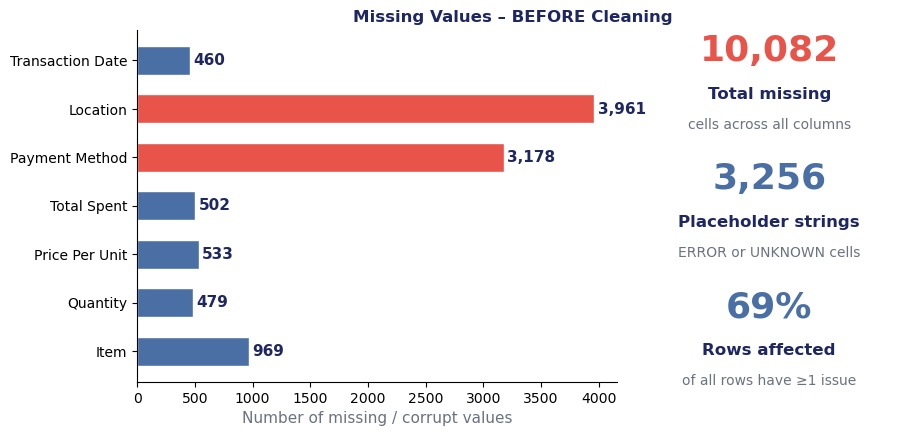

In [4]:
#Visualisation before cleaning
#Replacing "ERROR" and "UNKNOWN" with NaN
df_check = df_original.replace(['ERROR', 'UNKNOWN'], pd.NA)
missing_before     = df_check.isnull().sum()
missing_before     = missing_before[missing_before > 0]
columns_before     = list(missing_before.index)
values_before      = list(missing_before.values)
colors_before      = ['#E8534A' if v > 1000 
                      else '#4A6FA5' 
                      for v in values_before]
total_missing      = int(missing_before.sum())
placeholder_count  = int(df_original.isin(['ERROR','UNKNOWN']).sum().sum())
rows_affected      = int((df_check.isnull().any(axis=1)).sum())
pct_affected       = round(rows_affected / len(df_original) * 100)

fig = plt.figure(figsize=(8, 4), facecolor='white')
fig.suptitle('Missing Values – BEFORE Cleaning',
             fontsize=12, fontweight='bold', color='#1E2761', y=1.01)
ax = fig.add_axes([0.03, 0.08, 0.60, 0.88])
bars = ax.barh(columns_before, values_before, color=colors_before,
               height=0.6, edgecolor='white')
for bar, val in zip(bars, values_before):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, color='#1E2761', fontweight='bold')
ax.set_xlabel('Number of missing / corrupt values', fontsize=11, color='#6B7280')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')

stats_before = [
    {'value': f'{total_missing:,}',      'title': 'Total missing',       'sub': 'cells across all columns',  'color': '#E8534A'},
    {'value': f'{placeholder_count:,}','title': 'Placeholder strings', 'sub': 'ERROR or UNKNOWN cells',     'color': '#4A6FA5'},
    {'value': f'{pct_affected}%',         'title': 'Rows affected',        'sub': 'of all rows have ≥1 issue', 'color': '#4A6FA5'},
]
for i, stat in enumerate(stats_before):
    card = fig.add_axes([0.66, 0.68 - i*0.32, 0.32, 0.28])
    card.set_facecolor('#F1F4F9')
    card.axis('off')
    card.text(0.5, 0.72, stat['value'], ha='center', fontsize=26,
              fontweight='bold', color=stat['color'], transform=card.transAxes)
    card.text(0.5, 0.38, stat['title'], ha='center', fontsize=12,
              fontweight='bold', color='#1E2761', transform=card.transAxes)
    card.text(0.5, 0.12, stat['sub'], ha='center', fontsize=10,
              color='#6B7280', transform=card.transAxes)
plt.show()

In [5]:
#--> Step 3: Cleaning the data <--
#Duplicate check
print ( df. duplicated().sum()) #show all duplicates

0


In [6]:
#Replace "ERROR" and "UNKNOWN" with empty (NaN)
# NaN means "Not a Number" 
# We replace the incorrect words ERROR and UNKNOWN with real emptiness
#Replace "ERROR" and "UNKNOWN" with empty (NaN)
# NaN means "Not a Number" 
# We replace the incorrect words ERROR and UNKNOWN with real emptiness
df = df.replace(["ERROR", "UNKNOWN"], pd.NA)
print(df.head(10))
df = df.replace("UNKNOWN",pd.NA)   # swap every "UNKNOWN" with empty
print(df.head(10))


  Transaction ID      Item Quantity Price Per Unit Total Spent  \
0    TXN_1961373    Coffee        2            2.0         4.0   
1    TXN_4977031      Cake        4            3.0        12.0   
2    TXN_4271903    Cookie        4            1.0        <NA>   
3    TXN_7034554     Salad        2            5.0        10.0   
4    TXN_3160411    Coffee        2            2.0         4.0   
5    TXN_2602893  Smoothie        5            4.0        20.0   
6    TXN_4433211      <NA>        3            3.0         9.0   
7    TXN_6699534  Sandwich        4            4.0        16.0   
8    TXN_4717867       NaN        5            3.0        15.0   
9    TXN_2064365  Sandwich        5            4.0        20.0   

   Payment Method  Location Transaction Date  
0     Credit Card  Takeaway       08.09.2023  
1            Cash  In-store       16.05.2023  
2     Credit Card  In-store       19.07.2023  
3            <NA>      <NA>       27.04.2023  
4  Digital Wallet  In-store       11.0

In [7]:
# Step 2: Remove rows where 'Item' is empty
df=df.dropna(subset=['Item'])
print('Remaining rows after removing empty Items:', len(df))
print(df.head())


Remaining rows after removing empty Items: 9031
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0        <NA>     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0            <NA>   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       08.09.2023  
1  In-store       16.05.2023  
2  In-store       19.07.2023  
3      <NA>       27.04.2023  
4  In-store       11.06.2023  


In [8]:
#Step 3: Converting Date to datetime format
df['Transaction Date']=pd.to_datetime(df['Transaction Date'], format='%d.%m.%Y', errors='coerce')
df=df.dropna(subset=['Transaction Date'])
df['Transaction Date']=df['Transaction Date'].apply(lambda d:d.replace(year=2026) 
                                                     if pd.notnull(d) else d)
print('Rows after dropping invalid dates:', len(df))
print(df['Transaction Date'].head(10))

Rows after dropping invalid dates: 8613
0    2026-09-08
1    2026-05-16
2    2026-07-19
3    2026-04-27
4    2026-06-11
5    2026-03-31
7    2026-10-28
9    2026-12-31
10   2026-11-07
12   2026-05-03
Name: Transaction Date, dtype: datetime64[ns]


In [9]:
#Filling missing Quantity values with median --> converting text into numbers
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity']=df['Quantity'].fillna(df.groupby('Item')['Quantity'].transform('median'))
print(df['Quantity'].head(10))

0     2.0
1     4.0
2     4.0
3     2.0
4     2.0
5     5.0
7     4.0
9     5.0
10    5.0
12    2.0
Name: Quantity, dtype: float64


In [10]:
print(df.columns.tolist())

['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [11]:
#Filling missing Quantity values with median 
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Price Per Unit'] = df['Price Per Unit'].fillna(df.groupby('Item')['Price Per Unit'].transform('median'))
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())

In [12]:
#Filling missing Payment Method values with mode
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

In [13]:
#Filling missing Location values with mode
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
print(df['Location'].head(10))

0     Takeaway
1     In-store
2     In-store
3     Takeaway
4     In-store
5     Takeaway
7     Takeaway
9     In-store
10    Takeaway
12    In-store
Name: Location, dtype: object


In [14]:
print("\nSummary statistics after cleaning:")
print("Rows after cleaning:", len(df))
print("\nEmpty values (should be 0):")
print(df.isnull().sum())


Summary statistics after cleaning:
Rows after cleaning: 8613

Empty values (should be 0):
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [15]:
#Step 4: Save cleaned CSV file
df.to_csv('c:\\Users\\raynu\\Desktop\\Data Quality and Data Wrangling\\Data Cleaning\\cleaned_cafe_sales.csv', index=False)

In [16]:
#Step 5: summary statistics
print(df.describe())

          Quantity  Price Per Unit  Total Spent               Transaction Date
count  8613.000000     8613.000000  8613.000000                           8613
mean      3.025659        3.130965     9.482294  2026-07-02 03:54:44.012539136
min       1.000000        1.000000     1.000000            2026-01-01 00:00:00
25%       2.000000        2.000000     4.000000            2026-04-01 00:00:00
50%       3.000000        3.000000     9.000000            2026-07-02 00:00:00
75%       4.000000        4.000000    12.000000            2026-10-03 00:00:00
max       5.000000        5.000000    25.000000            2026-12-31 00:00:00
std       1.388081        1.162298     5.834859                            NaN


In [17]:
#Step 7: Visualization of cleaned data
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size": 11,
})

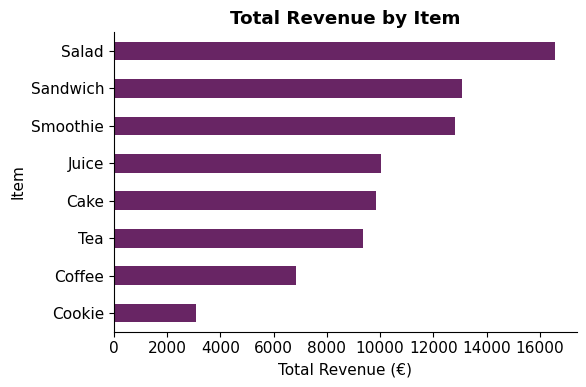

In [18]:
# -- Plot 1: Revenue by Item --
fig, ax = plt.subplots(figsize=(6, 4))

rev_item = df.groupby("Item")["Total Spent"].sum().sort_values()

rev_item.plot(kind="barh", ax=ax, color="#682564")

ax.set_title("Total Revenue by Item", fontweight="bold")
ax.set_xlabel("Total Revenue (€)")
plt.tight_layout()
plt.show()


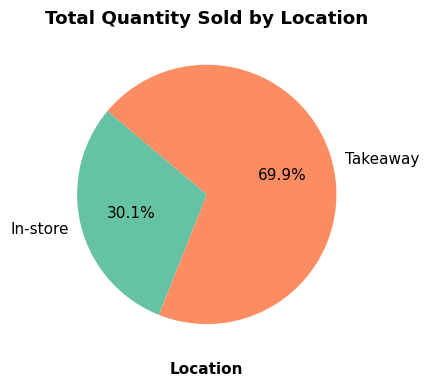

In [19]:
# -- Plot 2: Quantity Sold by Location --
fig, ax = plt.subplots(figsize=(6, 4))
qty_location = df.groupby("Location")["Quantity"].sum().sort_values()
ax.pie(qty_location, 
       labels=qty_location.index, 
       autopct="%1.1f%%", 
       startangle=140, 
       colors=sns.color_palette("Set2"))
ax.set_title("Total Quantity Sold by Location", fontweight="bold")
ax.set_xlabel("Location", fontweight="bold")
plt.tight_layout()
plt.show()



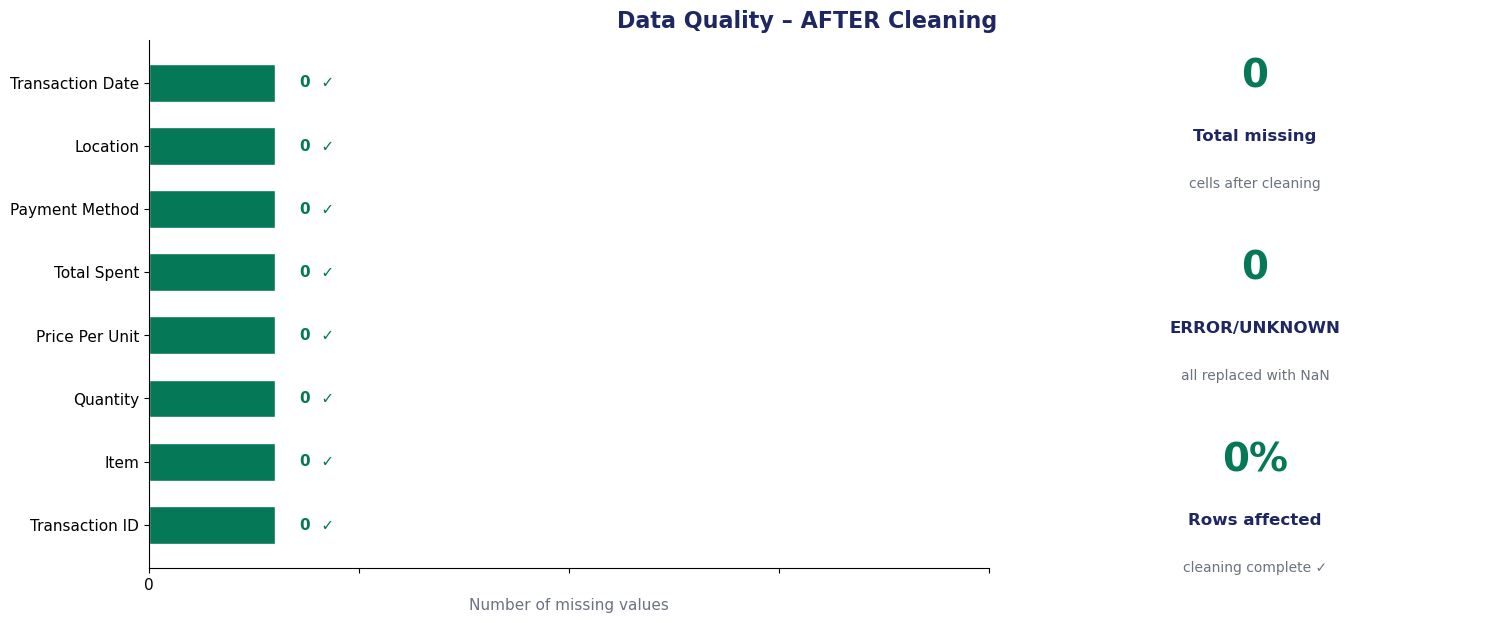

In [22]:
missing_after = df.isnull().sum()
columns_after = list(missing_after.index)
values_after  = list(missing_after.values)
total_after   = int(missing_after.sum())
rows_after    = int((df.isnull().any(axis=1)).sum())
pct_after     = round(rows_after / len(df) * 100)

fig = plt.figure(figsize=(14, 6), facecolor='white')
fig.suptitle('Data Quality – AFTER Cleaning',
             fontsize=16, fontweight='bold', color='#1E2761', y=1.01)

ax = fig.add_axes([0.03, 0.08, 0.60, 0.88])

# All values are 0 — use fixed small bar to make chart visible
display_values = [0.15] * len(columns_after)  # tiny bars just for visual
bars = ax.barh(columns_after, display_values,
               color='#047857', height=0.6, edgecolor='white')

# Show real value (0) as label next to each bar
for bar, val in zip(bars, values_after):
    ax.text(0.18, bar.get_y() + bar.get_height()/2,
            f'{val}  ✓', va='center', fontsize=11,
            color='#047857', fontweight='bold')

ax.set_xlabel('Number of missing values', fontsize=11, color='#6B7280')
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_xticklabels(['0', '', '', '', ''])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')

# 3 green stat cards on the right
stats_after = [
    {'value': str(total_after), 'title': 'Total missing',  'sub': 'cells after cleaning',  'color': '#047857'},
    {'value': '0',              'title': 'ERROR/UNKNOWN',  'sub': 'all replaced with NaN', 'color': '#047857'},
    {'value': f'{pct_after}%',  'title': 'Rows affected',  'sub': 'cleaning complete ✓',   'color': '#047857'},
]
for i, stat in enumerate(stats_after):
    card = fig.add_axes([0.66, 0.68 - i*0.32, 0.32, 0.28])
    card.set_facecolor('#ECFDF5')
    card.axis('off')
    card.text(0.5, 0.72, stat['value'], ha='center', fontsize=28,
              fontweight='bold', color=stat['color'], transform=card.transAxes)
    card.text(0.5, 0.40, stat['title'], ha='center', fontsize=12,
              fontweight='bold', color='#1E2761', transform=card.transAxes)
    card.text(0.5, 0.12, stat['sub'], ha='center', fontsize=10,
              color='#6B7280', transform=card.transAxes)

plt.savefig('data_quality_after_cleaning.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()